# Donchian-Breakout -- does the 20-day channel hold up on its own?
### The Turtles' famous entry, stripped to its skeleton and tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Better_than_SMA%3F: Not_supported](https://img.shields.io/badge/Better_than_SMA%3F-Not_supported-8b949e?style=flat-square)

In the 1980s, two traders turned beginners into millionaires with a system whose entry rule fit on an index card: **buy when price makes a new 20-day high; sell when it makes a new 20-day low.** That rule -- the Donchian channel breakout -- is still all over trading forums today, usually shorn of the rest of the Turtle machinery. This notebook asks the simple question: does the 20-day channel, *on its own*, beat just buying and holding the index?

> **This is the plain-language layer.** Want the t-stats, the permutation placebo and the capacity maths? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from donchian_breakout import data, strategy as st

TICKER = "SPY"
N      = 20
COST   = 2.0   # one-way bps

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-23).
R = dict(
    n=8400, start="1993-01-29", end="2026-06-12", fp="bc9ada8a0d6f",
    in_mkt=62.2, n_switches=203,
    bh_cagr=10.82, bh_sharpe=0.553, bh_vol=18.59, bh_dd=-55.19, bh_t=3.67,
    dc_cagr=5.16, dc_sharpe=0.465, dc_vol=10.81, dc_dd=-41.86, dc_t=2.90,
    sma_cagr=3.68, sma_sharpe=0.325, sma_vol=11.13, sma_dd=-44.33, sma_t=1.94,
    rn_cagr=3.72, rn_sharpe=0.258, rn_vol=14.16, rn_dd=-70.05, rn_t=1.57,
    t_vs_bh=-2.32, t_vs_random=0.66, t_vs_sma=0.94,
    perm_real_bps=2.05, perm_p=0.83,
    sharpe_0bps=0.477, sharpe_1bps=0.471, sharpe_2bps=0.465,
    sharpe_5bps=0.449, sharpe_10bps=0.420,
    w10_sh=0.331, w10_t=-3.03, w20_sh=0.465, w20_t=-2.32,
    w55_sh=0.523, w55_t=-1.89, w100_sh=0.603, w100_t=-1.44,
    ls_sharpe=-0.015, ls_cagr=-0.27, ls_dd=-62.86, ls_t=-2.34,
    panel={
        "SPY": (0.465, 0.553, -2.32), "QQQ": (0.349, 0.385, -1.32),
        "IWM": (0.498, 0.461, -0.53), "TLT": (0.217, 0.255, -0.75),
        "GLD": (0.324, 0.553, -2.29), "USO": (0.183, -0.195, 1.57),
        "UUP": (-0.069, 0.197, -1.59),
    },
    syn_null_dc=-0.414, syn_null_bh=-0.295, syn_null_t=0.11, syn_null_p=0.92,
    syn_tr_dc=0.052, syn_tr_bh=-0.446, syn_tr_t=2.24, syn_tr_p=0.044,
)

HAVE_REAL = data.have_real(TICKER)
print("real SPY cache present:", HAVE_REAL)

if HAVE_REAL:
    bars = data.load_real(TICKER)
    exp  = st.run_experiment(bars, n=N, cost_bps=COST, allow_short=False, random_seed=42)
    s_bh, s_dc, s_sma, s_rn = exp["bh"], exp["donchian"], exp["sma"], exp["random"]
    sig  = st.breakout_signal(bars, n=N, allow_short=False)
    bt   = st.run_backtest(bars, sig, cost_bps=COST)
    in_mkt = exp["in_market_frac"]
else:
    bars = sig = bt = None
    s_bh  = dict(cagr=R["bh_cagr"]/100, sharpe=R["bh_sharpe"], vol_ann=R["bh_vol"]/100, max_drawdown=R["bh_dd"]/100, tstat=R["bh_t"])
    s_dc  = dict(cagr=R["dc_cagr"]/100, sharpe=R["dc_sharpe"], vol_ann=R["dc_vol"]/100, max_drawdown=R["dc_dd"]/100, tstat=R["dc_t"])
    s_sma = dict(cagr=R["sma_cagr"]/100, sharpe=R["sma_sharpe"], vol_ann=R["sma_vol"]/100, max_drawdown=R["sma_dd"]/100, tstat=R["sma_t"])
    s_rn  = dict(cagr=R["rn_cagr"]/100, sharpe=R["rn_sharpe"], vol_ann=R["rn_vol"]/100, max_drawdown=R["rn_dd"]/100, tstat=R["rn_t"])
    exp   = dict(t_vs_bh=R["t_vs_bh"], t_vs_random=R["t_vs_random"], t_vs_sma=R["t_vs_sma"])
    in_mkt = R["in_mkt"]/100


real SPY cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the breakout beat buy-and-hold? | **No.** Sharpe **0.465** vs **0.553** -- and the gap is statistically real *against* it (*t* = -2.32). |
| Is its timing better than a coin flip? | **No.** A block-shuffle placebo says random in/out schedules with the same exposure beat the real rule **83%** of the time. |
| Is the channel better than a plain moving average? | **No.** It's a statistical tie with an SMA(20) cross (*t* = +0.94); both lose to buy-and-hold. |
| Does it do *anything*? | **Lower drawdown** (-42% vs -55%) -- but only because it sits in cash 38% of the time. That's cheaper to buy with a static stock/cash split. |

> The breakout's own track record looks positive only because it is long most of the time in a market that rises. Once you ask the honest question -- *better than just holding?* -- the answer is a clean no.

## 1 -- The claim

> *'Buy a new 20-day high; sell a new 20-day low. A new high means the trend is up, so you ride it; a new low means the trend has turned, so you step aside. This single rule -- the channel breakout -- was the entry engine of the Turtle traders, who turned a few thousand dollars into tens of millions.'*

The logic is clean: a 20-day high is, by definition, evidence that the recent trend is up. If markets *trend* -- if a rise tends to beget another rise -- then entering on the breakout and riding it should harvest that momentum. The catch the folklore skips: the Turtles' result also leaned on volatility-based sizing, pyramiding, dozens of *futures* markets, and an exit rule. Here we isolate just the **20-day channel on one equity index** and ask whether *that piece* carries the magic.

## 2 -- So what?

If a parameter-light breakout genuinely beat buy-and-hold on the most liquid index on Earth, it would be close to a free lunch -- anyone could run it from a phone. And it would say something deep about markets: that a simple new-high signal predicts future returns, i.e. that prices trend in a way you can monetise.

The honest bar is not 'does the rule make money' -- almost any long-biased rule makes money in a rising market. The bar is **does it beat just holding the index**, after costs, on a risk-adjusted basis. That's a much harder test, and it's the one that separates a real edge from repackaged beta.

## 3 -- How would we even know?

Four checks keep us honest:

1. **The buy-and-hold race.** The breakout must beat just holding SPY, net of costs, on Sharpe -- not merely make a positive number.
2. **The random-timing control.** A coin that's in the market the same fraction of days but on *random* days. If the breakout doesn't beat this, its 'timing' is empty.
3. **The plain-SMA benchmark.** A simple 'price above its 20-day average' rule -- same window, same costs. If the fancy channel can't beat the simplest moving average, the channel machinery adds nothing.
4. **The synthetic positive control.** A simulated tape where we *plant* a real trend. The rule must light up there (proving the test can detect a breakout edge) and stay quiet on a pure random walk.

## 4 -- The teardown -- let's actually look

**First, the big picture: who ends up where?**

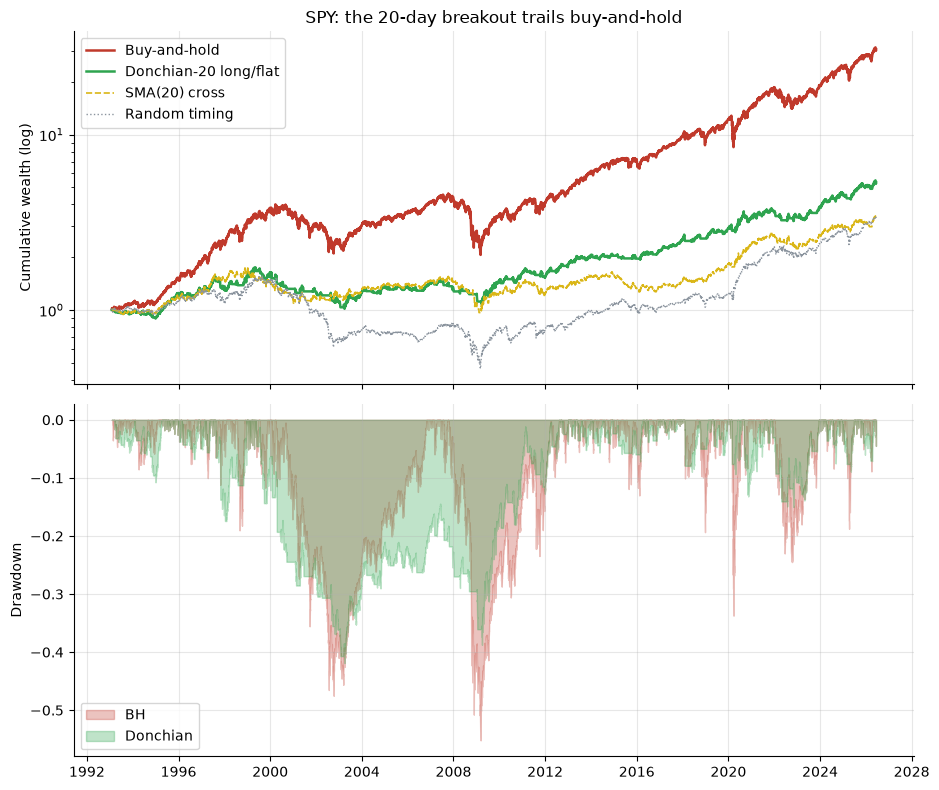

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(9.5, 8.0), sharex=True)
if HAVE_REAL:
    sig_sma = st.sma_cross_signal(bars, n=N)
    sig_rn  = st.random_timing_signal(sig, seed=42)
    bt_sma  = st.run_backtest(bars, sig_sma, cost_bps=COST)
    bt_rn   = st.run_backtest(bars, sig_rn,  cost_bps=COST)
    cum_bh  = np.exp(bt['r_bh'].cumsum())
    cum_dc  = np.exp(bt['r_strategy'].cumsum())
    cum_sma = np.exp(bt_sma['r_strategy'].cumsum())
    cum_rn  = np.exp(bt_rn['r_strategy'].cumsum())
    axes[0].plot(cum_bh.index,  cum_bh,  c=RED,   lw=1.8, label='Buy-and-hold')
    axes[0].plot(cum_dc.index,  cum_dc,  c=GREEN, lw=1.8, label='Donchian-20 long/flat')
    axes[0].plot(cum_sma.index, cum_sma, c=AMBER, lw=1.2, label='SMA(20) cross', ls='--')
    axes[0].plot(cum_rn.index,  cum_rn,  c=GREY,  lw=1.0, label='Random timing', ls=':')
    for col, lbl, c in [('r_bh','BH',RED), ('r_strategy','Donchian',GREEN)]:
        cum = np.exp(bt[col].cumsum()); dd = cum/cum.cummax()-1
        axes[1].fill_between(dd.index, dd, 0, alpha=0.3, color=c, label=lbl)
else:
    axes[0].text(0.5,0.5,'Cache not available\nRun verify.py --fetch',ha='center',va='center',transform=axes[0].transAxes)
axes[0].set_yscale('log'); axes[0].set_ylabel('Cumulative wealth (log)')
axes[0].legend(); axes[0].set_title('SPY: the 20-day breakout trails buy-and-hold')
axes[1].set_ylabel('Drawdown'); axes[1].legend(); plt.tight_layout(); plt.show()


Buy-and-hold (red) ends well above the breakout (green). The channel rule *does* ride a shallower drawdown (-42% vs -55%) -- but look at the random-timing line (grey dotted): being out of the market on *random* days actually produces the *worst* drawdown of all (-70%). And the plain SMA (amber dashed) ends up roughly where the Donchian channel does. The fancy channel is buying you essentially what a simple moving average does, for less than just holding.

**Now the honest scorecard -- Sharpe, drawdown, return for all four arms:**

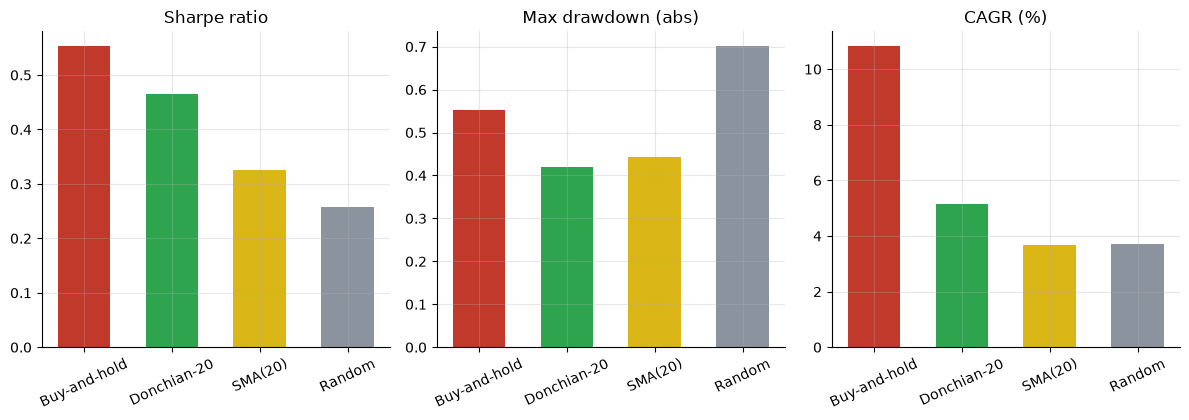

Donchian Sharpe 0.465 vs BH 0.553 (return-diff HAC t = -2.32)
Donchian vs SMA(20): t = +0.94  |  vs random: t = +0.66


In [3]:
labels = ['Buy-and-hold','Donchian-20','SMA(20)','Random']
sh  = [s_bh['sharpe'], s_dc['sharpe'], s_sma['sharpe'], s_rn['sharpe']]
dd  = [abs(s_bh['max_drawdown']), abs(s_dc['max_drawdown']), abs(s_sma['max_drawdown']), abs(s_rn['max_drawdown'])]
cg  = [s_bh['cagr']*100, s_dc['cagr']*100, s_sma['cagr']*100, s_rn['cagr']*100]
cols= [RED, GREEN, AMBER, GREY]
fig, ax = plt.subplots(1,3,figsize=(12,4.3))
for i,(vals,title) in enumerate([(sh,'Sharpe ratio'),(dd,'Max drawdown (abs)'),(cg,'CAGR (%)')]):
    bars_ = ax[i].bar(labels, vals, color=cols, width=0.6)
    ax[i].set_title(title); ax[i].tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()
print(f'Donchian Sharpe {s_dc["sharpe"]:.3f} vs BH {s_bh["sharpe"]:.3f} '
      f'(return-diff HAC t = {exp["t_vs_bh"]:+.2f})')
print(f'Donchian vs SMA(20): t = {exp["t_vs_sma"]:+.2f}  |  vs random: t = {exp["t_vs_random"]:+.2f}')


Buy-and-hold wins on Sharpe (0.553) and CAGR (10.8%). The breakout's only 'win' is lower drawdown -- and the random-timing arm shows that simply being out of the market on random days makes drawdown *worse*, so even that isn't timing skill, it's just exposure. The breakout's edge over a plain SMA is a statistical non-event (*t* = +0.94).

## 5 -- The verdict

- **Signal -- NONE.** The breakout loses to buy-and-hold on a risk-adjusted basis (*t* = -2.32), ties a coin flip with the same exposure, and a block-shuffle placebo says random schedules beat it 83% of the time. Its positive-looking track record is bull-market beta, not timing skill.
- **Tradability -- MIRAGE.** Even *gross* it trails buy-and-hold (0.477 vs 0.553); the short-selling version goes negative; it fails across a 7-asset panel.
- **Better than a plain SMA? -- NOT SUPPORTED.** Donchian channel vs SMA(20): *t* = +0.94. The channel's extra machinery buys nothing over the simplest filter.

## 6 -- Could you actually trade it?

There's no edge to monetise here, but it's worth showing *why* costs aren't even the problem -- the rule is cheap to run (only ~6 switches a year). It loses on merit, gross:

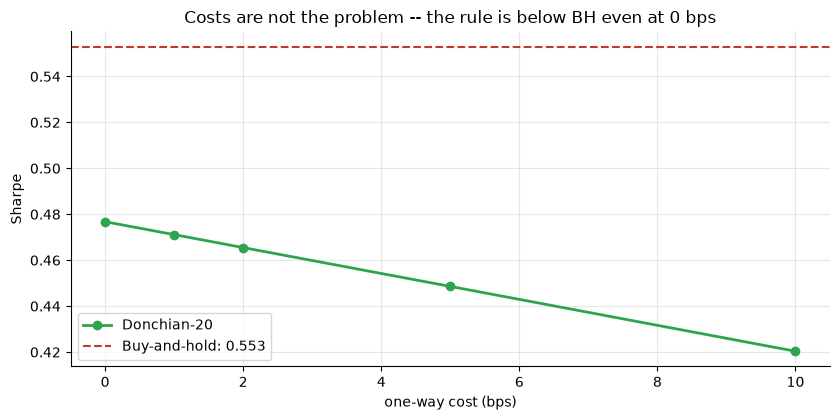

In [4]:
if HAVE_REAL:
    costs = [0.0,1.0,2.0,5.0,10.0]; shs=[]
    for c in costs:
        e = st.run_experiment(bars, n=N, cost_bps=c, random_seed=42)
        shs.append(e['donchian']['sharpe'])
else:
    costs=[0.0,1.0,2.0,5.0,10.0]
    shs=[R['sharpe_0bps'],R['sharpe_1bps'],R['sharpe_2bps'],R['sharpe_5bps'],R['sharpe_10bps']]
fig, ax = plt.subplots(figsize=(8.5,4.3))
ax.plot(costs, shs, 'o-', c=GREEN, lw=2, label='Donchian-20')
ax.axhline(R['bh_sharpe'], ls='--', c=RED, label=f'Buy-and-hold: {R["bh_sharpe"]:.3f}')
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('Sharpe'); ax.legend()
ax.set_title('Costs are not the problem -- the rule is below BH even at 0 bps')
plt.tight_layout(); plt.show()


The green line never reaches the red dashed buy-and-hold line, not even at zero cost. When a rule loses *gross*, transaction costs are beside the point -- there is no edge for costs to eat. The honest bottom line: you would have done better, with less effort and less tax drag, just holding the index.

## 7 -- Going further

- **The rest of the Turtle.** The breakout is one piece; [Study 103 -- Turtle-Trader](../../103-turtle-trader/) runs the *full* system (ATR sizing + pyramiding + exit). Read together, they ask how much of the legend is the entry vs the rest.
- **Slow channels and diversified futures.** Breakouts earn a real premium when spread across *many* trending markets (commodities, FX, rates) -- not on one equity index. Window matters too: the slowest channels here close the Sharpe gap to BH (but never clear it). A fork on a futures panel is the fair home for this rule.
- **Why a slow SMA *does* work.** [Study 110 -- Faber-Timing](../../110-faber-timing/) shows the 200-day SMA genuinely reduces risk -- because it times volatility, which a fast 20-day channel doesn't. The contrast is the lesson.

*Think the channel deserves a friendlier test? Fork this, point it at a diversified futures basket or a much slower window, and show it beats buy-and-hold there. That's the bar.*